In [1]:
import numpy as np
import h5py
import re
from pathlib import Path
import matplotlib.pyplot as plt

Path("fig").mkdir(exist_ok=True)

plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.family": "Times New Roman",
    "font.size": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

In [2]:
# -- Variable-step data (new top-level h5 layout; compatible with old segmented files) --
file_vs = "data/ns_SDIRK2_mr_SAV_bursting_50_4_4_vs.h5"

traj_keys = ["tn", "q", "Energy", "Enstrophy", "Palinstrophy", "Mx", "CPU_time"]
optional_traj_keys = ["Energy_rate", "Enstrophy_rate"]

def load_bursting_h5(path):
    """Load either the new top-level layout or the old segmented group layout."""
    with h5py.File(path, "r") as f:
        if "tn" in f and "Omega" in f:
            out = {
                "layout": "top-level",
                "tn": f["tn"][:],
                "tn_s": f["tn_s"][:],
                "tau": f["tau"][:] if "tau" in f else np.asarray(f.attrs.get("tau")),
                "q": f["q"][:],
                "Mx": f["Mx"][:],
                "Energy": f["Energy"][:],
                "Enstrophy": f["Enstrophy"][:],
                "Palinstrophy": f["Palinstrophy"][:],
                "CPU_time": f["CPU_time"][:],
                "Omega": f["Omega"][:],
            }
            for key in optional_traj_keys:
                if key in f:
                    out[key] = f[key][:]
            return out

        intervals = []
        for name in f.keys():
            m = re.match(r"t_([0-9.]+)_([0-9.]+)", name)
            if m:
                intervals.append((float(m.group(1)), float(m.group(2)), name))
        intervals.sort(key=lambda x: x[0])
        if not intervals:
            raise ValueError(f"No top-level datasets or t_* groups found in {path}")

        arrays = {k: [] for k in traj_keys}
        optional_arrays = {k: [] for k in optional_traj_keys}
        arrays["tn_s"] = []
        omega_list = []
        tau_list = []
        for i, (_, _, name) in enumerate(intervals):
            grp = f[name]
            skip = 1 if i > 0 else 0
            for k in traj_keys:
                arrays[k].append(grp[k][skip:])
            for k in optional_traj_keys:
                if k in grp:
                    optional_arrays[k].append(grp[k][skip:])
            arrays["tn_s"].append(grp["tn_s"][skip:])
            omega_list.append(grp["Omega"][skip:])
            if "tau" in grp:
                tau_list.append(grp["tau"][skip:])

        out = {
            "layout": "segmented",
            "segments": [name for _, _, name in intervals],
            **{k: np.concatenate(v) for k, v in arrays.items()},
            "Omega": np.concatenate(omega_list, axis=0),
        }
        for k, chunks in optional_arrays.items():
            if chunks:
                out[k] = np.concatenate(chunks)
        if tau_list:
            out["tau"] = np.concatenate(tau_list)
        return out

data_vs = load_bursting_h5(file_vs)
tn_vs        = data_vs["tn"]
tn_s_vs      = data_vs["tn_s"]
tau_vs       = data_vs["tau"]
q_vs         = data_vs["q"]
Mx_vs        = data_vs["Mx"]
Energy_vs    = data_vs["Energy"]
Energy_rate_vs = data_vs.get("Energy_rate")
Enstrophy_vs = data_vs["Enstrophy"]
Enstrophy_rate_vs = data_vs.get("Enstrophy_rate")
Palin_vs     = data_vs["Palinstrophy"]
CPU_vs       = data_vs["CPU_time"]
Omega_vs     = data_vs["Omega"]

if len(tau_vs) != len(tn_vs) - 1:
    raise ValueError(f"Expected one adaptive step per time interval, got len(tau)={len(tau_vs)} and len(tn)={len(tn_vs)}")
if not np.allclose(tau_vs, np.diff(tn_vs), rtol=1e-9, atol=1e-12):
    raise ValueError("Stored adaptive steps do not match np.diff(tn)")

def adaptive_time_samples(values, t0=None, t1=None):
    """Pair right-endpoint values with interval overlap weights on [t0, t1]."""
    values = np.asarray(values, dtype=np.float64)
    if len(values) != len(tn_vs):
        raise ValueError(f"Expected {len(tn_vs)} nodal values, got {len(values)}")
    left, right = tn_vs[:-1], tn_vs[1:]
    lower = -np.inf if t0 is None else float(t0)
    upper = np.inf if t1 is None else float(t1)
    overlap = np.minimum(right, upper) - np.maximum(left, lower)
    mask = overlap > 0.0
    return values[1:][mask], overlap[mask]

print(f"VS  | layout: {data_vs['layout']}")
print(f"VS  | tn:     {tn_vs.shape}, tn_s: {tn_s_vs.shape}, Omega: {Omega_vs.shape}")
print(f"VS  | t range: [{tn_s_vs[0]:.3f}, {tn_s_vs[-1]:.3f}]")
print(f"VS  | tau range: [{tau_vs.min():.2e}, {tau_vs.max():.2e}]")
print(f"VS  | stored rates: Energy_rate={Energy_rate_vs is not None}, Enstrophy_rate={Enstrophy_rate_vs is not None}")


VS  | layout: top-level
VS  | tn:     (1882784,), tn_s: (1001,), Omega: (1001, 64, 64)
VS  | t range: [0.000, 10000.000]
VS  | tau range: [5.00e-04, 1.00e-02]
VS  | stored rates: Energy_rate=True, Enstrophy_rate=True


In [3]:
# -- Fixed-step data: load two fixed time-step runs without overwriting them --
fixed_step_files = {
    "tau=1e-3": {
        "path": "data/ns_SDIRK2_mr_SAV_bursting_50_4_4_0.001.h5",
        "tau": 1.0e-3,
    },
    "tau=5e-4": {
        "path": "data/ns_SDIRK2_mr_SAV_bursting_50_4_4_0.0005.h5",
        "tau": 5.0e-4,
    },
}

def summarize_bursting_run(label, data, path, tau_value=None):
    print(f"{label:<10} | file:   {path}")
    print(f"{label:<10} | layout: {data['layout']}")
    if data["layout"] == "segmented":
        print(f"{label:<10} | segments: {data['segments']}")
    print(
        f"{label:<10} | tn:     {data['tn'].shape}, "
        f"tn_s: {data['tn_s'].shape}, Omega: {data['Omega'].shape}"
    )
    print(f"{label:<10} | t range: [{data['tn_s'][0]:.3f}, {data['tn_s'][-1]:.3f}]")
    if tau_value is not None:
        print(f"{label:<10} | tau:    {tau_value:.1e}")
    print()

fs_runs = {}
for label, meta in fixed_step_files.items():
    fs_runs[label] = load_bursting_h5(meta["path"])
    fs_runs[label]["path"] = meta["path"]
    fs_runs[label]["tau_value"] = meta["tau"]
    summarize_bursting_run(label, fs_runs[label], meta["path"], meta["tau"])


tau=1e-3   | file:   data/ns_SDIRK2_mr_SAV_bursting_50_4_4_0.001.h5
tau=1e-3   | layout: top-level
tau=1e-3   | tn:     (10000001,), tn_s: (1001,), Omega: (1001, 64, 64)
tau=1e-3   | t range: [0.000, 10000.000]
tau=1e-3   | tau:    1.0e-03

tau=5e-4   | file:   data/ns_SDIRK2_mr_SAV_bursting_50_4_4_0.0005.h5
tau=5e-4   | layout: top-level
tau=5e-4   | tn:     (20000001,), tn_s: (1001,), Omega: (1001, 64, 64)
tau=5e-4   | t range: [0.000, 10000.000]
tau=5e-4   | tau:    5.0e-04



In [4]:
# -- Explicit aliases for the two fixed-step runs --
data_fs_1e3 = fs_runs["tau=1e-3"]
data_fs_5e4 = fs_runs["tau=5e-4"]

tn_fs_1e3        = data_fs_1e3["tn"]
tn_s_fs_1e3      = data_fs_1e3["tn_s"]
q_fs_1e3         = data_fs_1e3["q"]
Mx_fs_1e3        = data_fs_1e3["Mx"]
Energy_fs_1e3    = data_fs_1e3["Energy"]
Enstrophy_fs_1e3 = data_fs_1e3["Enstrophy"]
Palin_fs_1e3     = data_fs_1e3["Palinstrophy"]
CPU_fs_1e3       = data_fs_1e3["CPU_time"]
Omega_fs_1e3     = data_fs_1e3["Omega"]
tau_fs_1e3       = data_fs_1e3["tau_value"]

tn_fs_5e4        = data_fs_5e4["tn"]
tn_s_fs_5e4      = data_fs_5e4["tn_s"]
q_fs_5e4         = data_fs_5e4["q"]
Mx_fs_5e4        = data_fs_5e4["Mx"]
Energy_fs_5e4    = data_fs_5e4["Energy"]
Enstrophy_fs_5e4 = data_fs_5e4["Enstrophy"]
Palin_fs_5e4     = data_fs_5e4["Palinstrophy"]
CPU_fs_5e4       = data_fs_5e4["CPU_time"]
Omega_fs_5e4     = data_fs_5e4["Omega"]
tau_fs_5e4       = data_fs_5e4["tau_value"]

# Backward-compatible aliases below keep older cells usable; new comparisons use fixed_run_specs.
default_fs_key = "tau=1e-3"
data_fs = fs_runs[default_fs_key]
tau_fs = data_fs["tau_value"]

tn_fs        = data_fs["tn"]
tn_s_fs      = data_fs["tn_s"]
q_fs         = data_fs["q"]
Mx_fs        = data_fs["Mx"]
Energy_fs    = data_fs["Energy"]
Enstrophy_fs = data_fs["Enstrophy"]
Palin_fs     = data_fs["Palinstrophy"]
CPU_fs       = data_fs["CPU_time"]
Omega_fs     = data_fs["Omega"]

print(f"Default fixed-step reference: {default_fs_key} (tau = {tau_fs:.1e})")


# Shared labels and colors for all comparisons.
fixed_run_specs = {
    "tau=1e-3": {
        "data": data_fs_1e3,
        "tau_value": tau_fs_1e3,
        "color": "C3",
        "label": r"Fixed step ($\tau=10^{-3}$)",
        "short_label": r"$\tau=10^{-3}$",
    },
    "tau=5e-4": {
        "data": data_fs_5e4,
        "tau_value": tau_fs_5e4,
        "color": "#6A5ACD",
        "label": r"Fixed step ($\tau=5\times10^{-4}$)",
        "short_label": r"$\tau=5\times10^{-4}$",
    },
}
adaptive_spec = {
    "data": data_vs,
    "color": "#2E8B57",
    "label": r"Adaptive step",
    "short_label": r"Adaptive",
}


Default fixed-step reference: tau=1e-3 (tau = 1.0e-03)


In [5]:
# ── Representative flow scales from time-averaged kinetic energy ──────────
#
# Energy is defined in the solver as
#   E(t) = 1/2 ||u(.,t)||_{L2(Ω)}^2.
# For Ω = [0,L]^2 with L = 2π, define the representative velocity by
#   U = sqrt( 2/(L^2 T) * int_0^T E(t) dt ),
# and then set
#   Re = U L / ν,   T_e = L / U.
#
# Thus U, Re, and T_e are representative constants over the averaging window,
# not instantaneous time series.

L_domain = 2 * np.pi
nu = 1 / 40
t_flow_start = 1000.0
t_flow_end = 10000.0

def integrate_over_window(time, values, t0, t1):
    time = np.asarray(time, dtype=np.float64)
    values = np.asarray(values, dtype=np.float64)

    order = np.argsort(time)
    time = time[order]
    values = values[order]

    finite = np.isfinite(time) & np.isfinite(values)
    time = time[finite]
    values = values[finite]

    # Remove duplicated segment boundaries before interpolating endpoints.
    time, unique_idx = np.unique(time, return_index=True)
    values = values[unique_idx]

    if t0 < time[0] or t1 > time[-1]:
        raise ValueError(
            f"Requested window [{t0}, {t1}] is outside the data range "
            f"[{time[0]}, {time[-1]}]."
        )

    interior = (time > t0) & (time < t1)
    t_window = np.concatenate(([t0], time[interior], [t1]))
    v_window = np.concatenate((
        [np.interp(t0, time, values)],
        values[interior],
        [np.interp(t1, time, values)],
    ))
    return np.trapezoid(v_window, t_window)

def representative_flow_scales(time, energy, t0=t_flow_start, t1=t_flow_end,
                               L=L_domain, nu=nu):
    window_length = t1 - t0
    if window_length <= 0:
        raise ValueError("The averaging window must have positive length.")

    energy_integral = integrate_over_window(time, energy, t0, t1)
    mean_energy = energy_integral / window_length
    U = np.sqrt(max(2 * mean_energy / L**2, 0.0))
    Re = U * L / nu
    Te = np.inf if U == 0 else L / U
    return {
        "energy_integral": energy_integral,
        "mean_energy": mean_energy,
        "U": U,
        "Re": Re,
        "Te": Te,
    }

def relative_difference(value, reference):
    return (value - reference) / reference

flow_scales_fixed = {
    key: representative_flow_scales(spec["data"]["tn"], spec["data"]["Energy"])
    for key, spec in fixed_run_specs.items()
}
flow_scales_vs = representative_flow_scales(tn_vs, Energy_vs)

# Backward-compatible default fixed-step aliases.
flow_scales_fs = flow_scales_fixed[default_fs_key]

rows = [
    (r"U", "U"),
    (r"Re", "Re"),
    (r"T_e", "Te"),
    (r"<E>", "mean_energy"),
    (r"int E dt", "energy_integral"),
]

print(f"Representative flow scales from {t_flow_start:g} <= t <= {t_flow_end:g}")
print("─" * 112)
print(
    f"{'Quantity':<12} {'Fixed 1e-3':>14} {'Fixed 5e-4':>14} "
    f"{'Adaptive':>14} {'Ada.-1e-3':>13} {'Ada.-5e-4':>13}"
)
print("─" * 112)
for label, key in rows:
    fs_1e3 = flow_scales_fixed["tau=1e-3"][key]
    fs_5e4 = flow_scales_fixed["tau=5e-4"][key]
    vs_value = flow_scales_vs[key]
    rel_1e3 = 100 * relative_difference(vs_value, fs_1e3)
    rel_5e4 = 100 * relative_difference(vs_value, fs_5e4)
    print(
        f"{label:<12} {fs_1e3:>14.6f} {fs_5e4:>14.6f} "
        f"{vs_value:>14.6f} {rel_1e3:>12.3f}% {rel_5e4:>12.3f}%"
    )
print("─" * 112)


Representative flow scales from 1000 <= t <= 10000
────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Quantity         Fixed 1e-3     Fixed 5e-4       Adaptive     Ada.-1e-3     Ada.-5e-4
────────────────────────────────────────────────────────────────────────────────────────────────────────────────
U                  1.323376       1.323795       1.326184        0.212%        0.180%
Re               332.600577     332.706096     333.306274        0.212%        0.180%
T_e                4.747847       4.746341       4.737795       -0.212%       -0.180%
<E>               34.569732      34.591671      34.716585        0.425%        0.361%
int E dt      311127.592054  311325.037258  312449.266594        0.425%        0.361%
────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [6]:
# ── Common plotting strides ────────────────────────────────────────────────
# Downsample dense time series only for plotting.
stride_fs = 500   # tn_fs has ~10^7 points -> keep ~20000
stride_vs = 50    # tn_vs has ~1.2×10^6 points -> keep ~24000

In [7]:
# ── Adaptive-step tau 与诊断量及其变化率的相关性 ───────────────────────────
#
# Compute correlations between tau and selected diagnostics X, and between tau
# and the available first-rate diagnostics. Higher-order finite-difference rates
# are intentionally omitted because they are noisy and not needed here.

t_corr = np.asarray(data_vs["tn"], dtype=np.float64)
tau_corr = np.asarray(data_vs["tau"], dtype=np.float64)

dt_corr = np.diff(t_corr)
if len(tau_corr) != len(dt_corr):
    raise ValueError(
        f"Expected one adaptive step per interval, got len(tau)={len(tau_corr)} and len(t)={len(t_corr)}"
    )

print(f"max |tau - dt| = {np.nanmax(np.abs(tau_corr - dt_corr)):.3e}")

def pearson_corr(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if len(x) < 2 or np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    return np.corrcoef(x, y)[0, 1]

def weighted_corr(x, y, w):
    x = np.asarray(x)
    y = np.asarray(y)
    w = np.asarray(w)
    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(w) & (w > 0)
    x, y, w = x[mask], y[mask], w[mask]
    if len(x) < 2:
        return np.nan
    mx = np.average(x, weights=w)
    my = np.average(y, weights=w)
    vx = np.average((x - mx) ** 2, weights=w)
    vy = np.average((y - my) ** 2, weights=w)
    if vx <= 0 or vy <= 0:
        return np.nan
    cov = np.average((x - mx) * (y - my), weights=w)
    return cov / np.sqrt(vx * vy)

def finite_difference_rate(values):
    values = np.asarray(values, dtype=np.float64)
    return np.diff(values) / dt_corr

def stored_or_fallback_rate(data, value_key, rate_key):
    if rate_key in data and len(data[rate_key]) == len(t_corr):
        return np.asarray(data[rate_key], dtype=np.float64)[1:], "stored"
    return finite_difference_rate(data[value_key]), "finite difference"

def interval_overlap_weights(t0):
    if not np.isfinite(t0):
        return tau_corr.copy()
    return np.maximum(0.0, t_corr[1:] - np.maximum(t_corr[:-1], t0))

def corr_row(window_name, name, values, weights, transform=lambda x: x):
    values = transform(np.asarray(values, dtype=np.float64))
    if values.shape != tau_corr.shape or weights.shape != tau_corr.shape:
        raise ValueError(f"Correlation arrays are not interval-aligned for {name}")
    mask = np.isfinite(values) & np.isfinite(tau_corr) & np.isfinite(weights) & (weights > 0)
    return {
        "window": window_name,
        "quantity": name,
        "N": int(np.count_nonzero(mask)),
        "corr(quantity, tau)": pearson_corr(values[mask], tau_corr[mask]),
        "weighted corr(quantity, tau)": weighted_corr(values[mask], tau_corr[mask], weights[mask]),
        "source": "",
    }

windows_corr = {
    "Full interval": -np.inf,
    "t >= 1000": 1000.0,
}

tau_correlation_rows = []
for window_name, t0 in windows_corr.items():
    weights_corr = interval_overlap_weights(t0)
    for name, values in {
        "Energy": data_vs["Energy"],
        "Enstrophy": data_vs["Enstrophy"],
        "Palinstrophy": data_vs["Palinstrophy"],
    }.items():
        tau_correlation_rows.append(
            corr_row(window_name, name, np.asarray(values, dtype=np.float64)[1:], weights_corr)
        )

    for name, value_key, rate_key in [
        ("|Energy rate|", "Energy", "Energy_rate"),
        ("|Enstrophy rate|", "Enstrophy", "Enstrophy_rate"),
    ]:
        rate_values, rate_source = stored_or_fallback_rate(data_vs, value_key, rate_key)
        row = corr_row(window_name, name, rate_values, weights_corr, transform=np.abs)
        row["source"] = rate_source
        tau_correlation_rows.append(row)

print("Correlation between adaptive tau and diagnostics / first rates")
print("─" * 100)

def print_tau_correlation_rows(rows):
    header = f"{'window':<14} {'quantity':<18} {'N':>9} {'corr':>11} {'weighted corr':>15} {'source':>18}"
    print(header)
    print("-" * len(header))
    for row in rows:
        print(
            f"{row['window']:<14} {row['quantity']:<18} {row['N']:>9d} "
            f"{row['corr(quantity, tau)']:>11.6f} {row['weighted corr(quantity, tau)']:>15.6f} "
            f"{row.get('source', ''):>18}"
        )

try:
    import pandas as pd
    tau_correlation_table = pd.DataFrame(tau_correlation_rows)
    try:
        from IPython.display import display as ipy_display
        ipy_display(tau_correlation_table.style.format({
            "corr(quantity, tau)": "{:.6f}",
            "weighted corr(quantity, tau)": "{:.6f}",
        }))
    except ImportError:
        print(tau_correlation_table.to_string(index=False))
except ImportError:
    tau_correlation_table = tau_correlation_rows
    print_tau_correlation_rows(tau_correlation_rows)


max |tau - dt| = 9.095e-13
Correlation between adaptive tau and diagnostics / first rates
────────────────────────────────────────────────────────────────────────────────────────────────────


,window,quantity,N,"corr(quantity, tau)","weighted corr(quantity, tau)",source
0,Full interval,Energy,1882783,-0.103237,-0.097445,
1,Full interval,Enstrophy,1882783,-0.332291,-0.373252,
2,Full interval,Palinstrophy,1882783,-0.566071,-0.573888,
3,Full interval,|Energy rate|,1882783,-0.172178,-0.190344,stored
4,Full interval,|Enstrophy rate|,1882783,-0.376940,-0.404035,stored
5,t >= 1000,Energy,1672975,-0.386387,-0.342656,
6,t >= 1000,Enstrophy,1672975,-0.553718,-0.540420,
7,t >= 1000,Palinstrophy,1672975,-0.594630,-0.586159,
8,t >= 1000,|Energy rate|,1672975,-0.440722,-0.443637,stored
9,t >= 1000,|Enstrophy rate|,1672975,-0.445844,-0.443140,stored


In [8]:
# ── 时间加权 KDE（1000 <= t <= 10000）──────────────────────────────────────
#
# gaussian_kde 的 weights 参数直接接受非均匀权重：
#   固定步长：等权重
#   变步长  ：weights = tau_vs，每个采样点按实际步长加权
#
# 两组固定步长数据按相近的物理时间间隔降采样，避免 KDE 点数差异过大。

from scipy.stats import gaussian_kde

kde_t_start = 1000.0
kde_t_end = 10000.0
fixed_kde_dt = 2.0e-2

# ── 固定步长稳态数据 ───────────────────────────────────────────────────────
fixed_kde_data = {}
fixed_kdes = {}
fixed_pdfs = {}

for label, data in fs_runs.items():
    tau_value = data["tau_value"]
    i0 = int(np.searchsorted(data["tn"], kde_t_start, side="left"))
    i1 = int(np.searchsorted(data["tn"], kde_t_end, side="right"))
    stride_kde = max(1, int(round(fixed_kde_dt / tau_value)))
    samples = data["Enstrophy"][i0:i1:stride_kde]
    fixed_kde_data[label] = samples
    fixed_kdes[label] = gaussian_kde(samples)
    print(
        f"{label:<10} KDE points : {len(samples):,} "
        f"(window=[{kde_t_start:g}, {kde_t_end:g}], stride={stride_kde}, tau={tau_value:.1e})"
    )

# ── 变步长稳态数据 ─────────────────────────────────────────────────────────
E_vs_ss, w_vs = adaptive_time_samples(Enstrophy_vs, kde_t_start, kde_t_end)

print(f"Adaptive   KDE points : {len(E_vs_ss):,}  (weighted by tau_vs, window=[{kde_t_start:g}, {kde_t_end:g}])")

# ── KDE ──────────────────────────────────────────────────────────────────
kde_vs = gaussian_kde(E_vs_ss, weights=w_vs)

Z_grid = np.linspace(50, 1500, 2000)
for label, kde in fixed_kdes.items():
    fixed_pdfs[label] = kde(Z_grid)
pdf_vs = kde_vs(Z_grid)

# Backward-compatible names used by later analysis cells.
kde_fs = fixed_kdes[default_fs_key]
pdf_fs = fixed_pdfs[default_fs_key]
E_fs_ss = fixed_kde_data[default_fs_key]


tau=1e-3   KDE points : 450,001 (window=[1000, 10000], stride=20, tau=1.0e-03)
tau=5e-4   KDE points : 450,001 (window=[1000, 10000], stride=40, tau=5.0e-04)
Adaptive   KDE points : 1,672,975  (weighted by tau_vs, window=[1000, 10000])


In [9]:
# ── 时间加权统计矩（稳态，t > 1000）─────────────────────────────────────────
#
# 固定步长：等权重，np.average / np.var 直接计算
# 变步长  ：weights = tau_vs，np.average(x, weights=w) = Σ(x_i·w_i)/Σw_i

t_cutoff = 1000

def weighted_moments(x, w=None):
    """返回 (均值, 二阶原点矩, 方差, 标准差)。"""
    mu1 = np.average(x, weights=w)
    mu2 = np.average(x**2, weights=w)
    var = np.average((x - mu1)**2, weights=w)
    std = np.sqrt(var)
    return mu1, mu2, var, std

def steady_enstrophy_samples_fixed(data, t0=t_cutoff):
    i0 = int(np.searchsorted(data["tn"], t0, side="left"))
    return data["Enstrophy"][i0:]

def steady_enstrophy_samples_adaptive(t0=t_cutoff):
    return adaptive_time_samples(Enstrophy_vs, t0=t0)

steady_moments_fixed = {}
for key, spec in fixed_run_specs.items():
    samples = steady_enstrophy_samples_fixed(spec["data"])
    mu1, mu2, var, std = weighted_moments(samples)
    steady_moments_fixed[key] = {
        "samples": samples,
        "mean": mu1,
        "second_moment": mu2,
        "variance": var,
        "std": std,
    }

E_vs_ss, w_vs = steady_enstrophy_samples_adaptive()
mu1_vs, mu2_vs, var_vs, std_vs = weighted_moments(E_vs_ss, w=w_vs)
steady_moments_vs = {
    "samples": E_vs_ss,
    "weights": w_vs,
    "mean": mu1_vs,
    "second_moment": mu2_vs,
    "variance": var_vs,
    "std": std_vs,
}

# Backward-compatible default fixed-step aliases used by later cells.
E_fs_ss = steady_moments_fixed[default_fs_key]["samples"]
mu1_fs = steady_moments_fixed[default_fs_key]["mean"]
mu2_fs = steady_moments_fixed[default_fs_key]["second_moment"]
var_fs = steady_moments_fixed[default_fs_key]["variance"]
std_fs = steady_moments_fixed[default_fs_key]["std"]

moment_rows = [
    ("Mean E[Z]", "mean"),
    ("Second moment E[Z^2]", "second_moment"),
    ("Variance Var[Z]", "variance"),
    ("Std[Z]", "std"),
]

print("Steady-state enstrophy moments on t >= 1000")
print("─" * 118)
print(
    f"{'Statistic':<24} {'Fixed 1e-3':>16} {'Fixed 5e-4':>16} "
    f"{'Adaptive':>16} {'Ada.-1e-3':>14} {'Ada.-5e-4':>14}"
)
print("─" * 118)
for label, key in moment_rows:
    fs_1e3 = steady_moments_fixed["tau=1e-3"][key]
    fs_5e4 = steady_moments_fixed["tau=5e-4"][key]
    vs_value = steady_moments_vs[key]
    rel_1e3 = 100 * (vs_value - fs_1e3) / fs_1e3
    rel_5e4 = 100 * (vs_value - fs_5e4) / fs_5e4
    print(
        f"{label:<24} {fs_1e3:>16.4f} {fs_5e4:>16.4f} "
        f"{vs_value:>16.4f} {rel_1e3:>13.3f}% {rel_5e4:>13.3f}%"
    )
print("─" * 118)


Steady-state enstrophy moments on t >= 1000
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Statistic                      Fixed 1e-3       Fixed 5e-4         Adaptive      Ada.-1e-3      Ada.-5e-4
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Mean E[Z]                        118.8310         122.0313         121.5697         2.305%        -0.378%
Second moment E[Z^2]           16519.0605       17375.5703       17333.6058         4.931%        -0.242%
Variance Var[Z]                 2398.2632        2483.9394        2554.4038         6.511%         2.837%
Std[Z]                            48.9721          49.8391          50.5411         3.204%         1.408%
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [17]:
# ── Total Variation Distance & 相对 L1 范数（稳态 KDE）───────────────────────
#
# 对每个固定步长 KDE 分别与自适应步长的时间加权 KDE 进行比较。

from scipy.stats import gaussian_kde

N_GRID = 5000

def ensure_enstrophy_kdes(t0=1000.0, t1=10000.0, fixed_dt=2.0e-2):
    """Create KDE objects if the KDE cell has not been run in this kernel."""
    global fixed_kde_data, fixed_kdes, fixed_pdfs, kde_vs, Z_grid, pdf_vs
    if all(name in globals() for name in ["fixed_kdes", "fixed_pdfs", "kde_vs", "Z_grid", "pdf_vs"]):
        return

    fixed_kde_data = {}
    fixed_kdes = {}
    fixed_pdfs = {}
    for key, spec in fixed_run_specs.items():
        data = spec["data"]
        tau_value = data["tau_value"]
        i0 = int(np.searchsorted(data["tn"], t0, side="left"))
        i1 = int(np.searchsorted(data["tn"], t1, side="right"))
        stride_kde = max(1, int(round(fixed_dt / tau_value)))
        samples = data["Enstrophy"][i0:i1:stride_kde]
        fixed_kde_data[key] = samples
        fixed_kdes[key] = gaussian_kde(samples)

    E_vs, w_vs_local = adaptive_time_samples(Enstrophy_vs, t0, t1)
    kde_vs = gaussian_kde(E_vs, weights=w_vs_local)

    Z_grid = np.linspace(50, 1500, 2000)
    for key, kde in fixed_kdes.items():
        fixed_pdfs[key] = kde(Z_grid)
    pdf_vs = kde_vs(Z_grid)

ensure_enstrophy_kdes(t0=kde_t_start if "kde_t_start" in globals() else 1000.0, 
                      t1=kde_t_end if "kde_t_end" in globals() else 10000.0)

# Backward-compatible default fixed-step aliases.
kde_fs = fixed_kdes[default_fs_key]
pdf_fs = fixed_pdfs[default_fs_key]

def interval_metrics(kde_p, kde_q, a, b, n=N_GRID):
    z = np.linspace(a, b, n)
    p = kde_p(z)
    q = kde_q(z)
    dz = z[1] - z[0]

    mass_p = np.trapezoid(p, dx=dz)
    mass_q = np.trapezoid(q, dx=dz)
    l1 = np.trapezoid(np.abs(p - q), dx=dz)
    tvd = 0.5 * l1
    rel_l1 = l1 / (0.5 * (mass_p + mass_q)) if (mass_p + mass_q) > 0 else np.nan
    return mass_p, mass_q, tvd, rel_l1

intervals = [
    ("(0,   120)", 0, 120),
    ("(120, 400)", 120, 500),
    ("(0,   500)", 0, 500),
]

print("KDE distance between each fixed-step run and the adaptive run")
print("─" * 102)
print(f"{'Fixed run':<12} {'Interval':<14} {'P_fixed':>9} {'P_adapt':>9} {'TVD':>12} {'Rel. L1':>12}")
print("─" * 102)
for key, spec in fixed_run_specs.items():
    for interval_label, a, b in intervals:
        mass_p, mass_q, tvd, rel_l1 = interval_metrics(fixed_kdes[key], kde_vs, a, b)
        print(
            f"{key:<12} {interval_label:<14} {mass_p:>9.4f} {mass_q:>9.4f} "
            f"{tvd:>12.6f} {rel_l1:>12.6f}"
        )
print("─" * 102)
print("P_fixed/P_adapt are probability masses on the selected interval.")
print("TVD = (1/2)∫|p_fixed-p_adapt| dx; Rel. L1 normalizes by the mean interval mass.")


KDE distance between each fixed-step run and the adaptive run
──────────────────────────────────────────────────────────────────────────────────────────────────────
Fixed run    Interval         P_fixed   P_adapt          TVD      Rel. L1
──────────────────────────────────────────────────────────────────────────────────────────────────────
tau=1e-3     (0,   120)        0.6913    0.6683     0.014790     0.043515
tau=1e-3     (120, 400)        0.3087    0.3318     0.012237     0.076423
tau=1e-3     (0,   500)        1.0000    1.0000     0.027027     0.054054
tau=5e-4     (0,   120)        0.6582    0.6683     0.008832     0.026633
tau=5e-4     (120, 400)        0.3418    0.3318     0.011784     0.069982
tau=5e-4     (0,   500)        1.0000    1.0000     0.020616     0.041232
──────────────────────────────────────────────────────────────────────────────────────────────────────
P_fixed/P_adapt are probability masses on the selected interval.
TVD = (1/2)∫|p_fixed-p_adapt| dx; Rel. L1 norm

In [11]:
# ── Fixed-step KDE comparison：tau=1e-3 vs tau=5e-4 ───────────────────────
#
# Compare the two fixed-step steady-state KDEs directly, using the same
# intervals and distance definitions as the adaptive-vs-fixed comparison.

from scipy.stats import gaussian_kde

if "ensure_enstrophy_kdes" in globals():
    ensure_enstrophy_kdes(
        t0=kde_t_start if "kde_t_start" in globals() else 1000.0,
        t1=kde_t_end if "kde_t_end" in globals() else 10000.0,
    )
elif "fixed_kdes" not in globals():
    fixed_kde_data = {}
    fixed_kdes = {}
    fixed_t0 = kde_t_start if "kde_t_start" in globals() else 1000.0
    fixed_t1 = kde_t_end if "kde_t_end" in globals() else 10000.0
    fixed_dt = fixed_kde_dt if "fixed_kde_dt" in globals() else 2.0e-2
    for key, spec in fixed_run_specs.items():
        data = spec["data"]
        tau_value = data["tau_value"]
        i0 = int(np.searchsorted(data["tn"], fixed_t0, side="left"))
        i1 = int(np.searchsorted(data["tn"], fixed_t1, side="right"))
        stride_kde = max(1, int(round(fixed_dt / tau_value)))
        samples = data["Enstrophy"][i0:i1:stride_kde]
        fixed_kde_data[key] = samples
        fixed_kdes[key] = gaussian_kde(samples)

N_GRID_FIXED_COMPARE = N_GRID if "N_GRID" in globals() else 5000

if "interval_metrics" not in globals():
    def interval_metrics(kde_p, kde_q, a, b, n=N_GRID_FIXED_COMPARE):
        z = np.linspace(a, b, n)
        p = kde_p(z)
        q = kde_q(z)
        dz = z[1] - z[0]
        mass_p = np.trapezoid(p, dx=dz)
        mass_q = np.trapezoid(q, dx=dz)
        l1 = np.trapezoid(np.abs(p - q), dx=dz)
        tvd = 0.5 * l1
        rel_l1 = l1 / (0.5 * (mass_p + mass_q)) if (mass_p + mass_q) > 0 else np.nan
        return mass_p, mass_q, tvd, rel_l1

if "intervals" not in globals():
    intervals = [
        ("(0,   120)", 0, 120),
        ("(120, 400)", 120, 400),
        ("(0,   500)", 0, 500),
    ]

fixed_a = "tau=1e-3"
fixed_b = "tau=5e-4"

print(f"KDE distance between fixed-step runs: {fixed_a} vs {fixed_b}")
print("─" * 100)
print(f"{'Interval':<14} {'P_1e-3':>10} {'P_5e-4':>10} {'TVD':>12} {'Rel. L1':>12}")
print("─" * 100)
for interval_label, a, b in intervals:
    mass_a, mass_b, tvd, rel_l1 = interval_metrics(fixed_kdes[fixed_a], fixed_kdes[fixed_b], a, b)
    print(
        f"{interval_label:<14} {mass_a:>10.4f} {mass_b:>10.4f} "
        f"{tvd:>12.6f} {rel_l1:>12.6f}"
    )
print("─" * 100)
print("P_1e-3/P_5e-4 are probability masses on the selected interval.")
print("TVD = (1/2)∫|p_1e-3-p_5e-4| dx; Rel. L1 normalizes by the mean interval mass.")


KDE distance between fixed-step runs: tau=1e-3 vs tau=5e-4
────────────────────────────────────────────────────────────────────────────────────────────────────
Interval           P_1e-3     P_5e-4          TVD      Rel. L1
────────────────────────────────────────────────────────────────────────────────────────────────────
(0,   120)         0.6913     0.6582     0.018142     0.053776
(120, 400)         0.3087     0.3418     0.018112     0.111365
(0,   500)         1.0000     1.0000     0.036254     0.072508
────────────────────────────────────────────────────────────────────────────────────────────────────
P_1e-3/P_5e-4 are probability masses on the selected interval.
TVD = (1/2)∫|p_1e-3-p_5e-4| dx; Rel. L1 normalizes by the mean interval mass.


CPU time source: cumulative values stored in each HDF5 file
CPU slope fitting window: [3000, 7000]
Dashed-line visual offset: 0.123 h
Adaptive slope : 0.0000 h/t   (intercept 0.007)
tau=1e-3   slope : 0.0003 h/t   speedup vs adaptive: 5.02×
tau=5e-4   slope : 0.0005 h/t   speedup vs adaptive: 9.77×


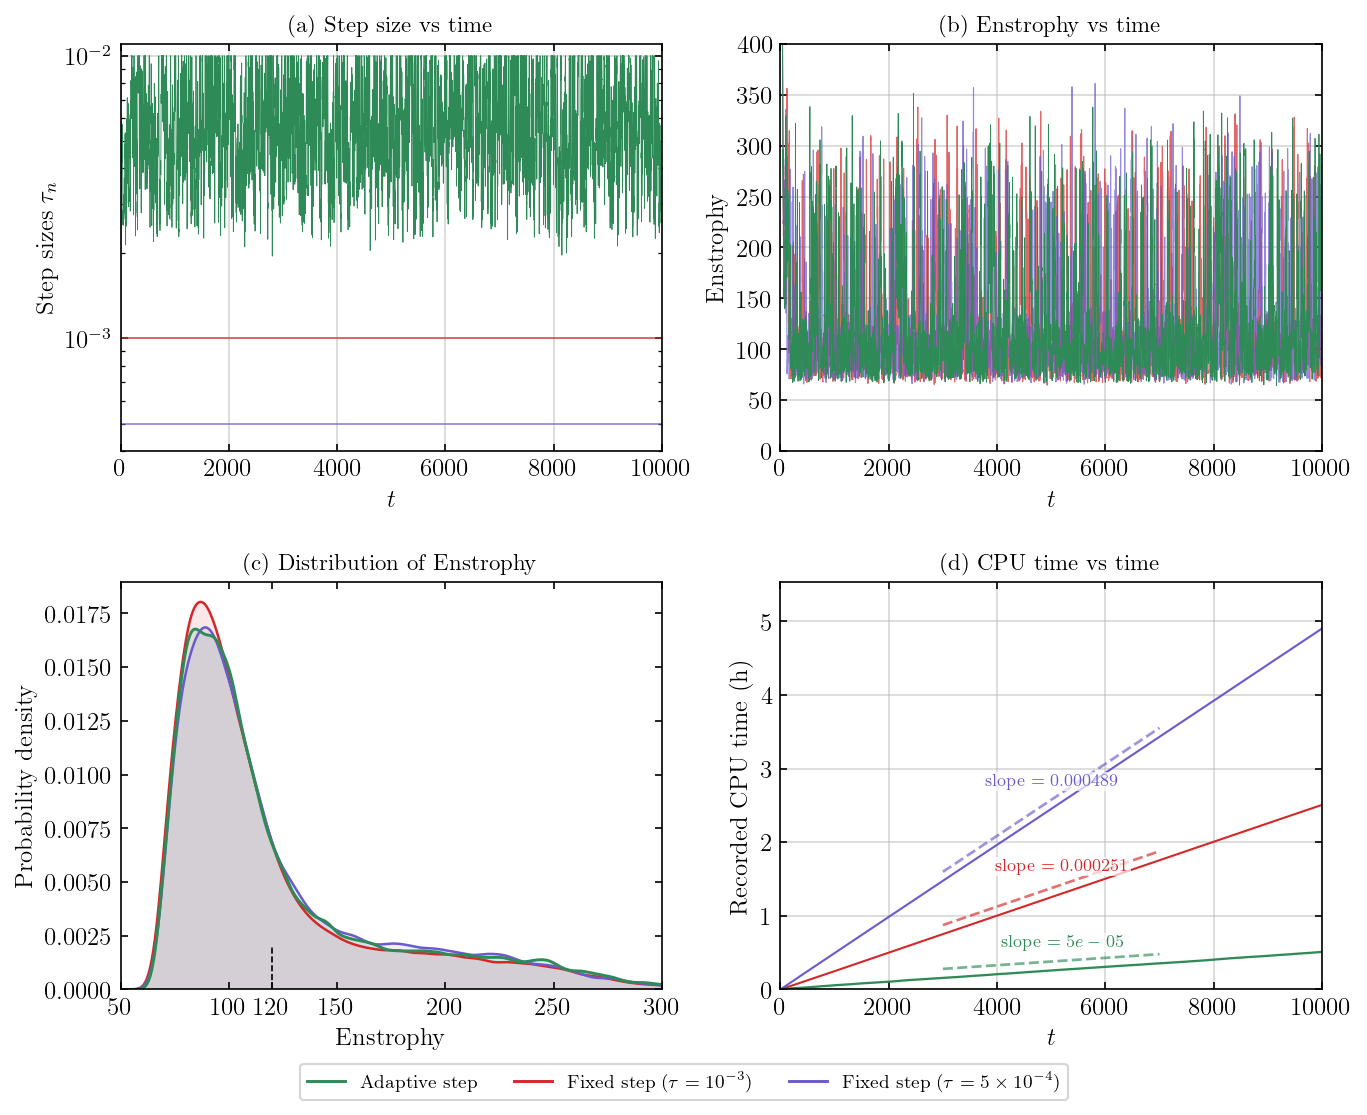

In [12]:
# ── Variable-step 自适应步长诊断：2×2 子图 ──────────────────────────────────
#
# (a) 步长 τ 随时间变化
# (b) Enstrophy 随时间变化
# (c) Enstrophy distribution comparison
# (d) 物理时间 t 与 CPU time 的关系

stride = 50   # ~1.2×10^6 → ~24000 点，足够线图

t   = tn_vs[::stride]
t_tau = tn_vs[1::stride]
tau = tau_vs[::stride]
E   = Enstrophy_vs[::stride]

fixed_plot_specs = fixed_run_specs
adaptive_color = adaptive_spec["color"]
adaptive_label = adaptive_spec["label"]

if "fixed_pdfs" not in globals() or "pdf_vs" not in globals() or "Z_grid" not in globals():
    from scipy.stats import gaussian_kde
    fixed_kde_data = {}
    fixed_kdes = {}
    fixed_pdfs = {}
    for key, spec in fixed_run_specs.items():
        data = spec["data"]
        tau_value = data["tau_value"]
        i0 = int(np.searchsorted(data["tn"], 1000.0, side="left"))
        i1 = int(np.searchsorted(data["tn"], 10000.0, side="right"))
        stride_kde = max(1, int(round(2.0e-2 / tau_value)))
        samples = data["Enstrophy"][i0:i1:stride_kde]
        fixed_kde_data[key] = samples
        fixed_kdes[key] = gaussian_kde(samples)
    E_vs_kde, w_vs_kde = adaptive_time_samples(Enstrophy_vs, 1000.0, 10000.0)
    kde_vs = gaussian_kde(E_vs_kde, weights=w_vs_kde)
    Z_grid = np.linspace(50, 1500, 2000)
    for key, kde in fixed_kdes.items():
        fixed_pdfs[key] = kde(Z_grid)
    pdf_vs = kde_vs(Z_grid)

fig, axes = plt.subplots(2, 2, figsize=(9, 7), constrained_layout=True, dpi=150)
fig.set_constrained_layout_pads(h_pad=0.05, hspace=0.08)

# ── (a) 步长随时间变化 ──────────────────────────────────────────────────────
ax = axes[0, 0]
for spec in fixed_plot_specs.values():
    tau_value = spec["data"]["tau_value"]
    ax.hlines(
        tau_value, 0, 10000,
        color=spec["color"], linewidth=0.8, alpha=0.75, linestyle="-",
        rasterized=True,
    )
ax.plot(t_tau, tau, color=adaptive_color, linewidth=0.4, rasterized=True)
ax.set_yscale("log")
ax.set_xlim(0, 10000)
ax.set_ylim(4.0e-4, max(1.2e-3, 1.1 * np.nanmax(tau)))
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"Step sizes $\tau_n$")
ax.set_title(r"(a) Step size vs time", loc="center", fontsize=11)
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.grid(alpha=0.5)

# ── (b) Enstrophy 随时间变化 ────────────────────────────────────────────────
ax = axes[0, 1]
for spec in fixed_plot_specs.values():
    data = spec["data"]
    stride_fixed = max(1, len(data["tn"]) // 20000)
    ax.plot(
        data["tn"][::stride_fixed],
        data["Enstrophy"][::stride_fixed],
        color=spec["color"], alpha=0.70, linewidth=0.55,
        rasterized=True,
    )
ax.plot(t, E, color=adaptive_color, linewidth=0.4, rasterized=True)
ax.set_xlim(0, 10000)
ax.set_ylim(0, 400)
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"Enstrophy")
ax.set_title(r"(b) Enstrophy vs time", loc="center", fontsize=11)
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.grid(alpha=0.5)

# ── (c) Enstrophy distribution comparison ────────────────────────────────
ax = axes[1, 0]
ax.vlines(120, 0, 0.002, color="k", linestyles="--", linewidth=0.8)
for key, spec in fixed_plot_specs.items():
    pdf = fixed_pdfs[key]
    ax.fill_between(Z_grid, pdf, color=spec["color"], alpha=0.10, linewidth=0)
    ax.plot(Z_grid, pdf, color=spec["color"], linewidth=1.2)
ax.fill_between(Z_grid, pdf_vs, color=adaptive_color, alpha=0.12, linewidth=0)
ax.plot(Z_grid, pdf_vs, color=adaptive_color, linewidth=1.4)

ax.set_xticks([50, 100, 120, 150, 200, 250, 300])
ax.set_xlim(50, 300)
ax.set_ylim(bottom=0)
ax.set_xlabel(r"Enstrophy")
ax.set_ylabel(r"Probability density")
ax.set_title(r"(c) Distribution of Enstrophy", fontsize=11)
ax.tick_params(which="both", direction="in", top=True, right=True)

# ── (d) 物理时间 t 与 CPU time 的关系 ──────────────────────────────────────
ax = axes[1, 1]

# Plot the cumulative CPU times stored in the HDF5 files without calibration.
fit_t0, fit_t1 = 3000.0, 7000.0

def cpu_hours(cpu_time):
    return np.asarray(cpu_time, dtype=np.float64) / 3600.0

def downsample_for_plot(x, target_points=20000):
    return max(1, len(x) // target_points)

def fit_cpu_slope(time, cpu_hours, t0=fit_t0, t1=fit_t1):
    mask = (time >= t0) & (time <= t1)
    if np.count_nonzero(mask) < 2:
        raise ValueError(f"Not enough points to fit CPU slope on [{t0}, {t1}].")
    return np.polyfit(time[mask], cpu_hours[mask], 1)

s_vs = downsample_for_plot(tn_vs)
t_vs_plot = tn_vs[::s_vs]
cpu_vs_hours = cpu_hours(CPU_vs[::s_vs])
ax.plot(
    t_vs_plot, cpu_vs_hours,
    color=adaptive_color, linewidth=1.1, rasterized=True, linestyle="-",
)

slope_rows = []
all_cpu_max = [np.nanmax(cpu_hours(CPU_vs))]
for key, spec in fixed_plot_specs.items():
    data = spec["data"]
    s_fix = downsample_for_plot(data["tn"])
    t_fix_plot = data["tn"][::s_fix]
    cpu_fix_hours = cpu_hours(data["CPU_time"][::s_fix])
    ax.plot(
        t_fix_plot, cpu_fix_hours,
        color=spec["color"], linewidth=1.0, linestyle="-", rasterized=True,
    )
    k_fix, b_fix = fit_cpu_slope(t_fix_plot, cpu_fix_hours)
    slope_rows.append((key, spec["label"], spec["color"], k_fix, b_fix))
    all_cpu_max.append(np.nanmax(cpu_hours(data["CPU_time"])))

k_ada, b_ada = fit_cpu_slope(t_vs_plot, cpu_vs_hours)

# 辅助拟合线（虚线，覆盖主要 t 范围；斜率只在该窗口内拟合）
t_line = np.array([fit_t0, fit_t1])
ymax_cpu = max(all_cpu_max)
fit_line_y_offset = 0.025 * ymax_cpu
label_x_positions = {"adaptive": 5200.0, "tau=1e-3": 5200.0, "tau=5e-4": 5000.0}

fit_label_specs = [
    ("adaptive", adaptive_color, k_ada, b_ada, r"Ada."),
]
fit_label_specs.extend(
    (key, color, k_fix, b_fix,
     r"$10^{-3}$" if key == "tau=1e-3" else r"$5\times10^{-4}$")
    for key, _, color, k_fix, b_fix in slope_rows
)

for key, color, slope, intercept, label in fit_label_specs:
    y_line = slope * t_line + intercept + fit_line_y_offset
    ax.plot(t_line, y_line, color=color,
            linewidth=1.3, linestyle="--", alpha=0.65)
    label_x = label_x_positions[key]
    label_y = slope * label_x + intercept + fit_line_y_offset
    ax.annotate(
        rf"slope $={slope:.3g}$",
        xy=(label_x, label_y), xytext=(0, 5), textcoords="offset points",
        color=color, fontsize=8.2, ha="center", va="bottom",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.70, pad=1.0),
    )

print("CPU time source: cumulative values stored in each HDF5 file")
print(f"CPU slope fitting window: [{fit_t0:g}, {fit_t1:g}]")
print(f"Dashed-line visual offset: {fit_line_y_offset:.3f} h")
print(f"Adaptive slope : {k_ada:.4f} h/t   (intercept {b_ada:.3f})")
for key, _, _, k_fix, b_fix in slope_rows:
    print(f"{key:<10} slope : {k_fix:.4f} h/t   speedup vs adaptive: {k_fix/k_ada:.2f}×")

ax.set_xlabel(r"$t$")
ax.set_ylabel(r"Recorded CPU time (h)")
ax.set_xlim(0, 10000)
ax.set_ylim(0, 1.10 * (ymax_cpu + fit_line_y_offset))
ax.set_title(r"(d) CPU time vs time", loc="center", fontsize=11)
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.grid(alpha=0.5)

legend_handles = [
    plt.Line2D([0], [0], color=adaptive_color, linewidth=1.4, label=adaptive_label),
]
legend_handles.extend(
    plt.Line2D([0], [0], color=spec["color"], linewidth=1.4, label=spec["label"])
    for spec in fixed_plot_specs.values()
)
fig.legend(handles=legend_handles, loc="lower center", ncol=3, fontsize=9,
           frameon=True, bbox_to_anchor=(0.5, -0.05))

plt.savefig("fig/vs_diagnostics.pdf", dpi=150, bbox_inches="tight")
plt.show()

CPU time source: cumulative values stored in each HDF5 file
CPU slope fitting window: [3000, 7000]
Adaptive slope : 0.0000 h/t  (intercept 0.007)
tau=5e-4   slope : 0.0005 h/t   speedup vs adaptive: 9.77×


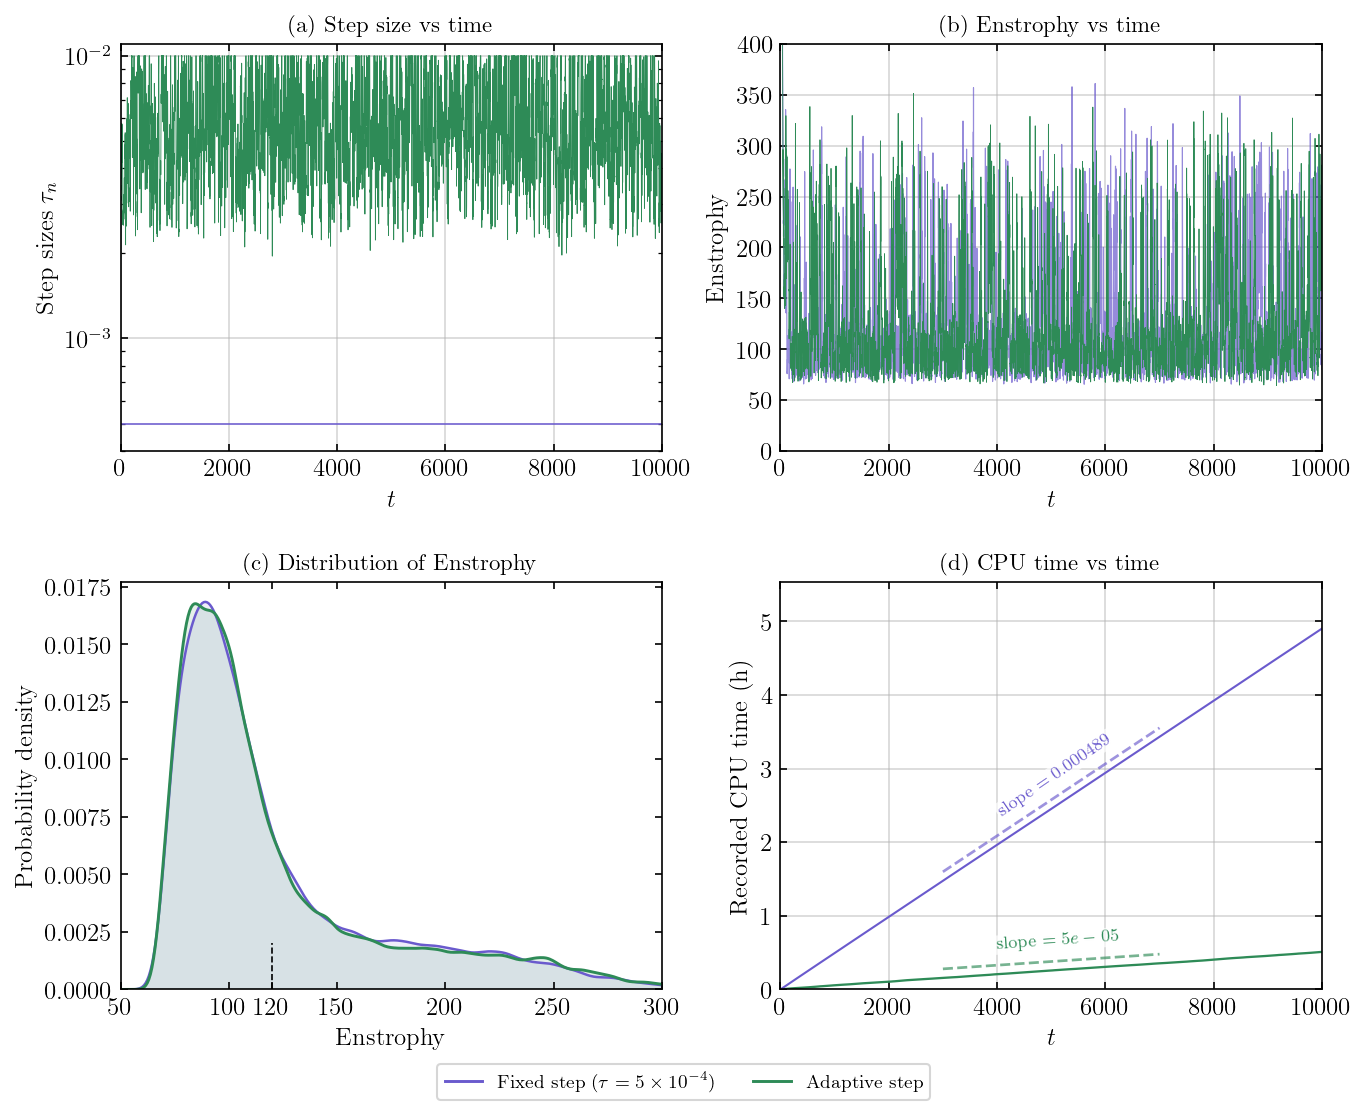

In [13]:
# ── Variable-step 自适应步长诊断：2×2 子图（只比较 5e-4 与 adaptive）──────
#
# (a) 步长 τ 随时间变化
# (b) Enstrophy 随时间变化
# (c) Enstrophy distribution comparison
# (d) 物理时间 t 与 CPU time 的关系

fixed_key = "tau=5e-4"
fixed_plot_specs_5e4 = {fixed_key: fixed_run_specs[fixed_key]}
fixed_spec_5e4 = fixed_plot_specs_5e4[fixed_key]
adaptive_color = adaptive_spec["color"]
adaptive_label = adaptive_spec["label"]

stride = 50
t = tn_vs[::stride]
t_tau = tn_vs[1::stride]
tau = tau_vs[::stride]
E = Enstrophy_vs[::stride]

if "fixed_pdfs" not in globals() or "pdf_vs" not in globals() or "Z_grid" not in globals():
    from scipy.stats import gaussian_kde
    fixed_kde_data = {}
    fixed_kdes = {}
    fixed_pdfs = {}
    for key, spec in fixed_plot_specs_5e4.items():
        data = spec["data"]
        tau_value = data["tau_value"]
        i0 = int(np.searchsorted(data["tn"], 1000.0, side="left"))
        i1 = int(np.searchsorted(data["tn"], 10000.0, side="right"))
        stride_kde = max(1, int(round(2.0e-2 / tau_value)))
        samples = data["Enstrophy"][i0:i1:stride_kde]
        fixed_kde_data[key] = samples
        fixed_kdes[key] = gaussian_kde(samples)
    E_vs_kde, w_vs_kde = adaptive_time_samples(Enstrophy_vs, 1000.0, 10000.0)
    kde_vs = gaussian_kde(E_vs_kde, weights=w_vs_kde)
    Z_grid = np.linspace(50, 1500, 2000)
    for key, kde in fixed_kdes.items():
        fixed_pdfs[key] = kde(Z_grid)
    pdf_vs = kde_vs(Z_grid)

fig, axes = plt.subplots(2, 2, figsize=(9, 7), constrained_layout=True, dpi=150)
fig.set_constrained_layout_pads(h_pad=0.05, hspace=0.08)

# ── (a) 步长随时间变化 ──────────────────────────────────────────────────────
ax = axes[0, 0]
tau_fixed = fixed_spec_5e4["data"]["tau_value"]
ax.hlines(
    tau_fixed, 0, 10000,
    color=fixed_spec_5e4["color"], linewidth=0.9, alpha=0.85, linestyle="-",
    rasterized=True,
)
ax.plot(t_tau, tau, color=adaptive_color, linewidth=0.4, rasterized=True)
ax.set_yscale("log")
ax.set_xlim(0, 10000)
ax.set_ylim(4.0e-4, max(1.2e-3, 1.1 * np.nanmax(tau)))
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"Step sizes $\tau_n$")
ax.set_title(r"(a) Step size vs time", loc="center", fontsize=11)
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.grid(alpha=0.5)

# ── (b) Enstrophy 随时间变化 ────────────────────────────────────────────────
ax = axes[0, 1]
data_5e4 = fixed_spec_5e4["data"]
stride_fixed = max(1, len(data_5e4["tn"]) // 20000)
ax.plot(
    data_5e4["tn"][::stride_fixed],
    data_5e4["Enstrophy"][::stride_fixed],
    color=fixed_spec_5e4["color"], alpha=0.70, linewidth=0.55,
    rasterized=True,
)
ax.plot(t, E, color=adaptive_color, linewidth=0.4, rasterized=True)
ax.set_xlim(0, 10000)
ax.set_ylim(0, 400)
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"Enstrophy")
ax.set_title(r"(b) Enstrophy vs time", loc="center", fontsize=11)
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.grid(alpha=0.5)

# ── (c) Enstrophy distribution comparison ────────────────────────────────
ax = axes[1, 0]
ax.vlines(120, 0, 0.002, color="k", linestyles="--", linewidth=0.8)
pdf_5e4 = fixed_pdfs[fixed_key]
ax.fill_between(Z_grid, pdf_5e4, color=fixed_spec_5e4["color"], alpha=0.10, linewidth=0)
ax.plot(Z_grid, pdf_5e4, color=fixed_spec_5e4["color"], linewidth=1.2)
ax.fill_between(Z_grid, pdf_vs, color=adaptive_color, alpha=0.12, linewidth=0)
ax.plot(Z_grid, pdf_vs, color=adaptive_color, linewidth=1.4)
ax.set_xticks([50, 100, 120, 150, 200, 250, 300])
ax.set_xlim(50, 300)
ax.set_ylim(bottom=0)
ax.set_xlabel(r"Enstrophy")
ax.set_ylabel(r"Probability density")
ax.set_title(r"(c) Distribution of Enstrophy", fontsize=11)
ax.tick_params(which="both", direction="in", top=True, right=True)

# ── (d) 物理时间 t 与 CPU time 的关系 ──────────────────────────────────────
ax = axes[1, 1]

fit_t0, fit_t1 = 3000.0, 7000.0

def cpu_hours(cpu_time):
    return np.asarray(cpu_time, dtype=np.float64) / 3600.0

def downsample_for_plot(x, target_points=20000):
    return max(1, len(x) // target_points)

def fit_cpu_slope(time, cpu_hours, t0=fit_t0, t1=fit_t1):
    mask = (time >= t0) & (time <= t1)
    if np.count_nonzero(mask) < 2:
        raise ValueError(f"Not enough points to fit CPU slope on [{t0}, {t1}].")
    return np.polyfit(time[mask], cpu_hours[mask], 1)

s_vs = downsample_for_plot(tn_vs)
t_vs_plot = tn_vs[::s_vs]
cpu_vs_hours = cpu_hours(CPU_vs[::s_vs])
ax.plot(
    t_vs_plot, cpu_vs_hours,
    color=adaptive_color, linewidth=1.1, rasterized=True, linestyle="-",
)

s_fix = downsample_for_plot(data_5e4["tn"])
t_fix_plot = data_5e4["tn"][::s_fix]

cpu_fix_hours = cpu_hours(data_5e4["CPU_time"][::s_fix])
ax.plot(
    t_fix_plot, cpu_fix_hours,
    color=fixed_spec_5e4["color"], linewidth=1.0, linestyle="-", rasterized=True,
)

k_ada, b_ada = fit_cpu_slope(t_vs_plot, cpu_vs_hours)
k_fix, b_fix = fit_cpu_slope(t_fix_plot, cpu_fix_hours)
ymax_cpu = max(
    np.nanmax(cpu_hours(CPU_vs)),
    np.nanmax(cpu_hours(data_5e4["CPU_time"])),
)
fit_line_y_offset = 0.025 * ymax_cpu
t_line = np.array([fit_t0, fit_t1])
label_x = fit_t1 - 3000.0

ax.set_xlim(0, 10000)
ax.set_ylim(0, 1.10 * (ymax_cpu + fit_line_y_offset))

def data_line_angle(ax, slope, intercept, x0, x1, y_offset=0.0):
    p0 = ax.transData.transform((x0, slope * x0 + intercept + y_offset))
    p1 = ax.transData.transform((x1, slope * x1 + intercept + y_offset))
    dx, dy = p1 - p0
    return np.degrees(np.arctan2(dy, dx))

for color, slope, intercept, label_dx in [
    (adaptive_color, k_ada, b_ada, 0.0),
    (fixed_spec_5e4["color"], k_fix, b_fix, 120.0),
]:
    y_line = slope * t_line + intercept + fit_line_y_offset
    ax.plot(t_line, y_line, color=color, linewidth=1.3, linestyle="--", alpha=0.65)
    label_xi = label_x + label_dx
    label_y = slope * label_xi + intercept + fit_line_y_offset
    angle = data_line_angle(ax, slope, intercept, fit_t0, fit_t1, fit_line_y_offset)
    ax.annotate(
        rf"slope $={slope:.3g}$",
        xy=(label_xi, label_y), xytext=(0, 6), textcoords="offset points",
        color=color, fontsize=8.2, ha="left", va="bottom",
        rotation=angle, rotation_mode="anchor",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.70, pad=1.0),
    )

print("CPU time source: cumulative values stored in each HDF5 file")
print(f"CPU slope fitting window: [{fit_t0:g}, {fit_t1:g}]")
print(f"Adaptive slope : {k_ada:.4f} h/t  (intercept {b_ada:.3f})")
print(f"{fixed_key:<10} slope : {k_fix:.4f} h/t   speedup vs adaptive: {k_fix/k_ada:.2f}×")

ax.set_xlabel(r"$t$")
ax.set_ylabel(r"Recorded CPU time (h)")
ax.set_title(r"(d) CPU time vs time", loc="center", fontsize=11)
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.grid(alpha=0.5)

legend_handles = [
    plt.Line2D([0], [0], color=fixed_spec_5e4["color"], linewidth=1.4, label=fixed_spec_5e4["label"]),
    plt.Line2D([0], [0], color=adaptive_color, linewidth=1.4, label=adaptive_label),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=2, fontsize=9,
           frameon=True, bbox_to_anchor=(0.5, -0.05))

plt.savefig("fig/vs_diagnostics_5e4_adaptive.pdf", dpi=150, bbox_inches="tight")
plt.show()


In [14]:
# Optional close-up diagnostics are omitted from the production run.

In [15]:
# ── Bursting 事件统计：连续超过阈值且峰值超过 200 的一段时间算作一个 burst ─────
#
# 对两个固定步长和自适应步长分别统计 burst 事件。

t_cutoff_burst = 1000
peak_threshold_burst = 200.0

def empty_burst_result(threshold, peak_threshold):
    empty = np.asarray([])
    return {
        "threshold": threshold,
        "peak_threshold": peak_threshold,
        "start_indices": empty.astype(int),
        "end_indices": empty.astype(int),
        "start_times": empty,
        "end_times": empty,
        "durations": empty,
        "time_intervals": empty,
        "clean_time_intervals": empty,
        "clean_interval_mask": np.asarray([], dtype=bool),
        "peak_values": empty,
        "count": 0,
        "clean_interval_count": 0,
        "max_duration": np.nan,
        "mean_duration": np.nan,
        "mean_interval": np.nan,
        "mean_clean_interval": np.nan,
    }

def detect_burst_segments(t, E, threshold, t_cutoff=0, peak_threshold=peak_threshold_burst):
    mask = t >= t_cutoff
    t_ss = t[mask]
    E_ss = E[mask]

    above = E_ss > threshold
    if not np.any(above):
        return empty_burst_result(threshold, peak_threshold)

    padded = np.r_[False, above, False]
    transitions = np.diff(padded.astype(np.int8))
    start_indices_all = np.flatnonzero(transitions == 1)
    end_indices_all = np.flatnonzero(transitions == -1) - 1
    peak_values_all = np.asarray([
        np.max(E_ss[i0:i1 + 1]) for i0, i1 in zip(start_indices_all, end_indices_all)
    ])

    keep = peak_values_all > peak_threshold
    if not np.any(keep):
        return empty_burst_result(threshold, peak_threshold)

    start_indices = start_indices_all[keep]
    end_indices = end_indices_all[keep]
    peak_values = peak_values_all[keep]

    start_times = t_ss[start_indices]
    end_times = t_ss[end_indices]
    durations = end_times - start_times
    time_intervals = np.diff(start_times)
    clean_interval_mask = np.asarray([
        not np.any(above[i_end + 1:i_next])
        for i_end, i_next in zip(end_indices[:-1], start_indices[1:])
    ], dtype=bool)
    clean_time_intervals = np.asarray([
        t_ss[i_next] - t_ss[i_end]
        for i_end, i_next in zip(end_indices[:-1], start_indices[1:])
    ])[clean_interval_mask]

    return {
        "threshold": threshold,
        "peak_threshold": peak_threshold,
        "start_indices": start_indices,
        "end_indices": end_indices,
        "start_times": start_times,
        "end_times": end_times,
        "durations": durations,
        "time_intervals": time_intervals,
        "clean_time_intervals": clean_time_intervals,
        "clean_interval_mask": clean_interval_mask,
        "peak_values": peak_values,
        "count": len(durations),
        "clean_interval_count": len(clean_time_intervals),
        "max_duration": np.max(durations),
        "mean_duration": np.mean(durations),
        "mean_interval": np.mean(time_intervals) if len(time_intervals) else np.nan,
        "mean_clean_interval": np.mean(clean_time_intervals) if len(clean_time_intervals) else np.nan,
    }

if "steady_moments_fixed" not in globals() or "steady_moments_vs" not in globals():
    def weighted_moments(x, w=None):
        mu1 = np.average(x, weights=w)
        mu2 = np.average(x**2, weights=w)
        var = np.average((x - mu1)**2, weights=w)
        std = np.sqrt(var)
        return mu1, mu2, var, std

    steady_moments_fixed = {}
    for key, spec in fixed_run_specs.items():
        data = spec["data"]
        i0 = int(np.searchsorted(data["tn"], 1000, side="left"))
        samples = data["Enstrophy"][i0:]
        mu1, mu2, var, std = weighted_moments(samples)
        steady_moments_fixed[key] = {
            "samples": samples,
            "mean": mu1,
            "second_moment": mu2,
            "variance": var,
            "std": std,
        }

    E_vs_ss, w_vs = adaptive_time_samples(Enstrophy_vs, t0=1000)
    mu1_vs, mu2_vs, var_vs, std_vs = weighted_moments(E_vs_ss, w=w_vs)
    steady_moments_vs = {
        "samples": E_vs_ss,
        "weights": w_vs,
        "mean": mu1_vs,
        "second_moment": mu2_vs,
        "variance": var_vs,
        "std": std_vs,
    }

burst_fixed = {}
for key, spec in fixed_run_specs.items():
    threshold = steady_moments_fixed[key]["mean"] + 2 * steady_moments_fixed[key]["std"]
    burst_fixed[key] = detect_burst_segments(
        spec["data"]["tn"], spec["data"]["Enstrophy"],
        threshold=threshold, t_cutoff=t_cutoff_burst,
    )

burst_vs = detect_burst_segments(
    tn_vs, Enstrophy_vs,
    threshold=steady_moments_vs["mean"] + 2 * steady_moments_vs["std"],
    t_cutoff=t_cutoff_burst,
)

# Backward-compatible default fixed-step alias.
burst_fs = burst_fixed[default_fs_key]

k_values_burst = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
burst_count_rows = []
for k in k_values_burst:
    threshold_vs = steady_moments_vs["mean"] + k * steady_moments_vs["std"]
    burst_k_vs = detect_burst_segments(tn_vs, Enstrophy_vs, threshold_vs, t_cutoff_burst)
    for key, spec in fixed_run_specs.items():
        threshold_fixed = steady_moments_fixed[key]["mean"] + k * steady_moments_fixed[key]["std"]
        burst_k_fixed = detect_burst_segments(
            spec["data"]["tn"], spec["data"]["Enstrophy"],
            threshold_fixed, t_cutoff_burst,
        )
        fixed_count = burst_k_fixed["count"]
        adaptive_count = burst_k_vs["count"]
        count_error_pct = 100 * abs(fixed_count - adaptive_count) / fixed_count if fixed_count > 0 else np.nan
        burst_count_rows.append({
            "k": k,
            "fixed run": key,
            "fixed threshold": threshold_fixed,
            "fixed burst count": fixed_count,
            "adaptive threshold": threshold_vs,
            "adaptive burst count": adaptive_count,
            "count error (%)": count_error_pct,
        })

try:
    import pandas as pd
    burst_count_table = pd.DataFrame(burst_count_rows)
    display(burst_count_table.style.format({
        "k": "{:.1f}",
        "fixed threshold": "{:.4f}",
        "adaptive threshold": "{:.4f}",
        "count error (%)": "{:.2f}",
    }))
except ImportError:
    burst_count_table = burst_count_rows
    print(f"{'k':>4} {'fixed run':>10} {'fixed thr.':>14} {'fixed':>8} {'adapt thr.':>14} {'adapt':>8} {'err (%)':>9}")
    print("-" * 86)
    for row in burst_count_rows:
        print(
            f"{row['k']:>4.1f} {row['fixed run']:>10} {row['fixed threshold']:>14.4f} "
            f"{row['fixed burst count']:>8d} {row['adaptive threshold']:>14.4f} "
            f"{row['adaptive burst count']:>8d} {row['count error (%)']:>9.2f}"
        )

def print_burst_duration_summary(label, burst):
    if burst["count"] == 0:
        print(
            f"{label} threshold = {burst['threshold']:.4f}, "
            f"peak > {burst['peak_threshold']:.1f}, count = 0"
        )
        return

    i_max = int(np.argmax(burst["durations"]))
    print(
        f"{label} threshold = {burst['threshold']:.4f}, "
        f"peak > {burst['peak_threshold']:.1f}, count = {burst['count']}"
    )
    print(f"  max duration  = {burst['max_duration']:.4f} "
          f"on [{burst['start_times'][i_max]:.4f}, {burst['end_times'][i_max]:.4f}], "
          f"peak = {burst['peak_values'][i_max]:.4f}")
    print(f"  mean duration = {burst['mean_duration']:.4f}")
    print(f"  mean interval = {burst['mean_interval']:.4f}")
    print(
        f"  clean intervals = {burst['clean_interval_count']}/{max(burst['count'] - 1, 0)}, "
        f"mean clean interval = {burst['mean_clean_interval']:.4f}"
    )

for key, spec in fixed_run_specs.items():
    print_burst_duration_summary(spec["label"], burst_fixed[key])
print_burst_duration_summary(adaptive_spec["label"], burst_vs)


,k,fixed run,fixed threshold,fixed burst count,adaptive threshold,adaptive burst count,count error (%)
0,1.0,tau=1e-3,167.8030,164,172.1109,185,12.80
1,1.0,tau=5e-4,171.8704,187,172.1109,185,1.07
2,2.0,tau=1e-3,216.7751,178,222.6520,198,11.24
3,2.0,tau=5e-4,221.7095,205,222.6520,198,3.41
4,3.0,tau=1e-3,265.7472,91,273.1931,85,6.59
5,3.0,tau=5e-4,271.5487,75,273.1931,85,13.33
6,4.0,tau=1e-3,314.7192,15,323.7342,11,26.67
7,4.0,tau=5e-4,321.3878,8,323.7342,11,37.50
8,5.0,tau=1e-3,363.6913,0,374.2753,0,nan
9,5.0,tau=5e-4,371.2269,0,374.2753,0,nan


Fixed step ($\tau=10^{-3}$) threshold = 216.7751, peak > 200.0, count = 178
  max duration  = 13.6450 on [4532.2590, 4545.9040], peak = 279.0645
  mean duration = 3.5661
  mean interval = 49.8858
  clean intervals = 177/177, mean clean interval = 46.3213
Fixed step ($\tau=5\times10^{-4}$) threshold = 221.7095, peak > 200.0, count = 205
  max duration  = 13.3155 on [3556.9995, 3570.3150], peak = 359.3581
  mean duration = 3.0159
  mean interval = 43.8602
  clean intervals = 204/204, mean clean interval = 40.8480
Adaptive step threshold = 222.6520, peak > 200.0, count = 198
  max duration  = 14.5729 on [5760.1664, 5774.7393], peak = 337.9996
  mean duration = 3.2593
  mean interval = 45.5429
  clean intervals = 197/197, mean clean interval = 42.2702


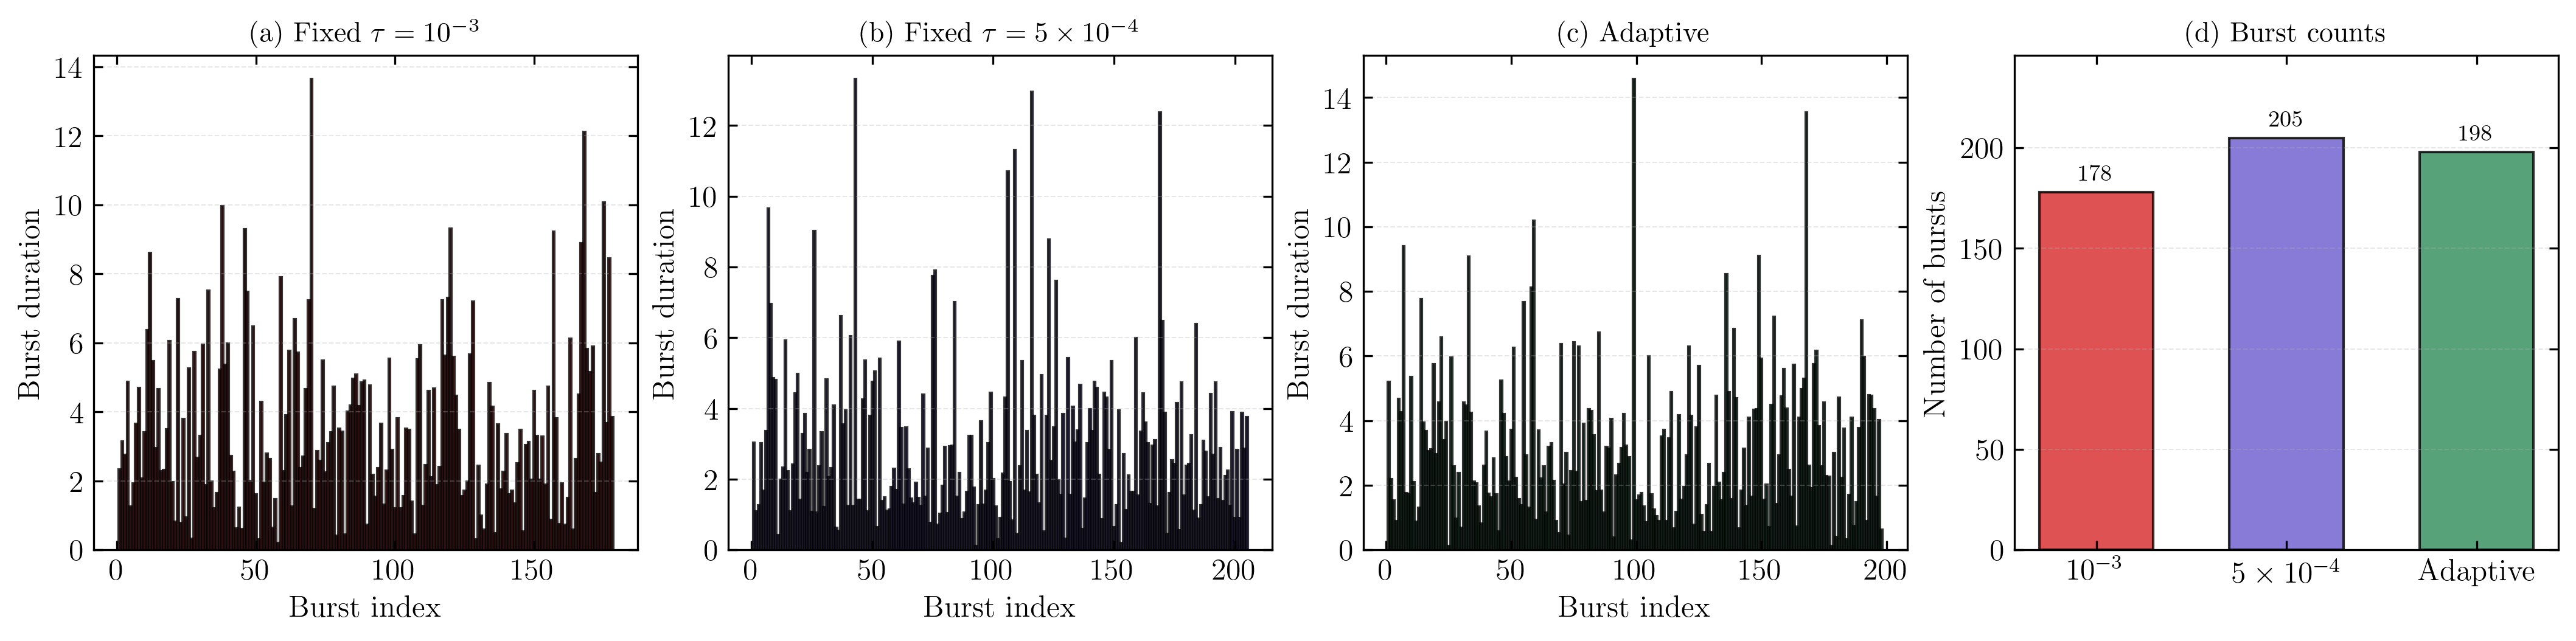

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.4), constrained_layout=True, dpi=300)

# ── (a)-(c) Burst duration bar plots ──────────────────────────────────────
duration_panels = [
    ("tau=1e-3", fixed_run_specs["tau=1e-3"], burst_fixed["tau=1e-3"], r"(a) Fixed $\tau=10^{-3}$"),
    ("tau=5e-4", fixed_run_specs["tau=5e-4"], burst_fixed["tau=5e-4"], r"(b) Fixed $\tau=5\times10^{-4}$"),
    ("adaptive", adaptive_spec, burst_vs, r"(c) Adaptive"),
]

for ax, (_, spec, burst, title) in zip(axes[:3], duration_panels):
    durations = burst["durations"]
    x_pos = np.arange(1, len(durations) + 1)
    ax.bar(x_pos, durations, color=spec["color"],
           edgecolor="black", alpha=0.8, width=0.6)
    ax.set_xlabel(r"Burst index")
    ax.set_ylabel(r"Burst duration")
    ax.set_title(title, fontsize=11)
    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.grid(axis="y", alpha=0.3, linestyle="dashed", linewidth=0.5)

# ── (d) Burst count comparison ───────────────────────────────────────────
ax = axes[3]
labels = [r"$10^{-3}$", r"$5\times10^{-4}$", r"Adaptive"]
counts = [burst_fixed["tau=1e-3"]["count"], burst_fixed["tau=5e-4"]["count"], burst_vs["count"]]
colors = [fixed_run_specs["tau=1e-3"]["color"], fixed_run_specs["tau=5e-4"]["color"], adaptive_spec["color"]]
x = np.arange(len(labels))
bars = ax.bar(x, counts, color=colors, edgecolor="black", alpha=0.8, width=0.6)
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_ylim(0, max(counts) * 1.20 if counts else 1)
ax.set_xticks(x, labels)
ax.set_ylabel(r"Number of bursts")
ax.set_title(r"(d) Burst counts", fontsize=11)
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.grid(axis="y", alpha=0.3, linestyle="dashed", linewidth=0.5)

plt.savefig("fig/bursting_event_comparison.pdf", dpi=300, bbox_inches="tight", pad_inches=0.2)
plt.show()

We consider the periodically forced two-dimensional Navier--Stokes problem on $\Omega=[0,2\pi]^2$ with $\nu=1/40$, $m=4$, perturbation amplitude $\varepsilon=4$, and mr-SAV parameter $\gamma=1000$. The initial streamfunction is the truncated Fourier perturbation used by the data-generation script, followed by an ETDRK4 warm-up on $0\leq t\leq1$ with step $2.5\times10^{-3}$. The subsequent computations use the SDIRK2-mr-SAV scheme on a periodic $64\times64$ grid up to $T=10000$. We compare fixed steps $\tau=10^{-3}$ and $\tau=5\times10^{-4}$ with an adaptive computation using $\tau_{\min}=10^{-5}$, $\tau_{\max}=10^{-2}$, $\mathrm{rtol}=5\times10^{-5}$, and $\mathrm{rtol}_q=10^{-2}$. The accepted adaptive steps range from $5\times10^{-4}$ to $10^{-2}$. Unless stated otherwise, statistics are evaluated on $1000\leq t\leq10000$; adaptive statistics pair each right-endpoint diagnostic with the corresponding interval length, including the exact overlap at the window boundary.

Figure~\ref{fig:adaptive_step_k} summarizes the long-time diagnostics. The adaptive step decreases during high-enstrophy episodes and returns toward its upper bound during quieter intervals. On $1000\leq t\leq10000$, the interval-aligned Pearson correlation between $\tau_n$ and the right-endpoint enstrophy is $-0.6871$, while the time-weighted correlation is $-0.6432$. The three enstrophy trajectories separate over long times but remain bounded in the stored computations. The adaptive run uses $1{,}179{,}126$ accepted steps and records $0.316$ CPU hours, compared with $10^7$ steps and $2.407$ hours for $\tau=10^{-3}$ and $2\times10^7$ steps and $4.794$ hours for $\tau=5\times10^{-4}$. Thus, on the recorded CPU-time metric, the adaptive run is approximately $7.63$ and $15.19$ times faster than the two fixed-step runs, respectively.

\begin{figure}[htbp]
    \centering
    \includegraphics[width=\linewidth]{fig/vs_diagnostics.pdf}
    \caption{Long-time SDIRK2-mr-SAV diagnostics for $\nu=1/40$ and $m=4$. (a) Accepted adaptive steps and the two fixed-step values. (b) Enstrophy histories. (c) Enstrophy probability densities on $1000\leq t\leq10000$, with interval-length weights for the adaptive run. (d) Cumulative CPU hours recorded in the HDF5 files; dashed slopes are fitted on $3000\leq t\leq7000$.}
    \label{fig:adaptive_step_k}
\end{figure}

The steady-state enstrophy moments are reported in Table~\ref{tab:moment_comparison}. The adaptive mean lies between the two fixed-step values, with relative differences of $-1.31\%$ and $1.77\%$. The variance is more sensitive: its differences from the two fixed-step baselines are $-9.17\%$ and $21.64\%$, respectively.

\begin{table}[htbp]
\centering
\caption{Enstrophy moments on $1000\leq t\leq10000$. Relative differences are $(\mathrm{Adaptive}-\mathrm{Fixed})/\mathrm{Fixed}$.}
\label{tab:moment_comparison}
\begin{tabular}{@{}lccccc@{}}
\toprule
Statistic & $\tau=10^{-3}$ & $\tau=5\times10^{-4}$ & Adaptive & Rel. diff. to $10^{-3}$ & Rel. diff. to $5\times10^{-4}$ \\
\midrule
Mean $\mathbb{E}[\mathcal{E}]$ & $92.7043$ & $89.8958$ & $91.4862$ & $-1.314\%$ & $1.769\%$ \\
Second moment $\mathbb{E}[\mathcal{E}^2]$ & $9573.8701$ & $8812.8558$ & $9259.6284$ & $-3.282\%$ & $5.070\%$ \\
Variance $\operatorname{Var}(\mathcal{E})$ & $979.7845$ & $731.6076$ & $889.9032$ & $-9.174\%$ & $21.637\%$ \\
Standard deviation & $31.3015$ & $27.0482$ & $29.8312$ & $-4.697\%$ & $10.289\%$ \\
\bottomrule
\end{tabular}
\end{table}

Representative flow scales are computed on the same window. With $\Delta T=9000$ and $L=2\pi$, we use
\[
U=\sqrt{\frac{2}{L^2\Delta T}\int_{1000}^{10000}E(t)\,dt},
\qquad Re_{\mathrm{eff}}=\frac{UL}{\nu},
\qquad T_e=\frac{L}{U}.
\]
The resulting values in Table~\ref{tab:flow_scales_comparison} differ by at most $0.21\%$ between the adaptive and fixed-step computations.

\begin{table}[htbp]
\centering
\caption{Representative flow scales on $1000\leq t\leq10000$.}
\label{tab:flow_scales_comparison}
\begin{tabular}{@{}lccccc@{}}
\toprule
Quantity & $\tau=10^{-3}$ & $\tau=5\times10^{-4}$ & Adaptive & Rel. diff. to $10^{-3}$ & Rel. diff. to $5\times10^{-4}$ \\
\midrule
Representative velocity $U$ & $1.170500$ & $1.169912$ & $1.169298$ & $-0.103\%$ & $-0.053\%$ \\
Effective Reynolds number $Re_{\mathrm{eff}}$ & $294.178617$ & $294.031073$ & $293.876632$ & $-0.103\%$ & $-0.053\%$ \\
Eddy turnover time $T_e$ & $5.367952$ & $5.370646$ & $5.373468$ & $0.103\%$ & $0.053\%$ \\
Mean kinetic energy $\overline{E}$ & $27.044081$ & $27.016960$ & $26.988586$ & $-0.205\%$ & $-0.105\%$ \\
\bottomrule
\end{tabular}
\end{table}

Table~\ref{tab:tv_comparison} compares each fixed-step kernel density estimate with the time-weighted adaptive estimate. Over $0\leq\mathcal{E}<500$, the total variation distances are $0.02097$ and $0.02290$. The relative discrepancy is larger in the low-probability bursting tail, so the full-range agreement should not be interpreted as equality of rare-event statistics.

\begin{table}[htbp]
\centering
\caption{KDE distances on $1000\leq t\leq10000$. Here $P$ denotes the probability mass in the indicated enstrophy range.}
\label{tab:tv_comparison}
\begin{tabular}{@{}llcccc@{}}
\toprule
Fixed baseline & Enstrophy range & $P_{\mathrm{fixed}}$ & $P_{\mathrm{adapt}}$ & TVD & Relative $L^1$ error \\
\midrule
$\tau=10^{-3}$ & $0\leq\mathcal{E}<120$ & $0.9025$ & $0.9103$ & $0.012833$ & $0.028315$ \\
$\tau=10^{-3}$ & $120\leq\mathcal{E}<400$ & $0.0975$ & $0.0897$ & $0.008141$ & $0.173963$ \\
$\tau=10^{-3}$ & $0\leq\mathcal{E}<500$ & $1.0000$ & $1.0000$ & $0.020973$ & $0.041947$ \\
$\tau=5\times10^{-4}$ & $0\leq\mathcal{E}<120$ & $0.9264$ & $0.9103$ & $0.014653$ & $0.031911$ \\
$\tau=5\times10^{-4}$ & $120\leq\mathcal{E}<400$ & $0.0736$ & $0.0897$ & $0.008244$ & $0.201999$ \\
$\tau=5\times10^{-4}$ & $0\leq\mathcal{E}<500$ & $1.0000$ & $1.0000$ & $0.022898$ & $0.045795$ \\
\bottomrule
\end{tabular}
\end{table}

A burst is defined as a connected interval on $t\geq1000$ for which $\mathcal{E}(t)$ exceeds the run-specific threshold $\mathbb{E}[\mathcal{E}]+k\operatorname{Std}(\mathcal{E})$ and whose peak exceeds $200$. Table~\ref{tab:burst_count_thresholds} shows that the event counts depend appreciably on the baseline and threshold. For $k=2$, the two fixed-step runs contain $53$ and $28$ bursts, whereas the adaptive run contains $41$.

\begin{table}[htbp]
\centering
\scriptsize
\caption{Burst thresholds and event counts on $t\geq1000$, with the additional requirement $\max\mathcal{E}>200$ for each connected event.}
\label{tab:burst_count_thresholds}
\begin{tabular}{@{}c cc cc cc cc@{}}
\toprule
$k$ & $\theta_{10^{-3}}$ & $N_{10^{-3}}$ & $\theta_{5\times10^{-4}}$ & $N_{5\times10^{-4}}$ & $\theta_{\rm adapt}$ & $N_{\rm adapt}$ & Err. to $10^{-3}$ & Err. to $5\times10^{-4}$ \\
\midrule
$1$ & $124.0058$ & $46$ & $116.9440$ & $28$ & $121.3174$ & $38$ & $17.39\%$ & $35.71\%$ \\
$2$ & $155.3073$ & $53$ & $143.9923$ & $28$ & $151.1487$ & $41$ & $22.64\%$ & $46.43\%$ \\
$3$ & $186.6088$ & $63$ & $171.0405$ & $39$ & $180.9799$ & $51$ & $19.05\%$ & $30.77\%$ \\
$4$ & $217.9103$ & $55$ & $198.0887$ & $46$ & $210.8112$ & $52$ & $5.45\%$ & $13.04\%$ \\
$5$ & $249.2118$ & $20$ & $225.1370$ & $30$ & $240.6424$ & $32$ & $60.00\%$ & $6.67\%$ \\
\bottomrule
\end{tabular}
\end{table}

\begin{figure}[htbp]
    \centering
    \includegraphics[width=\linewidth]{fig/bursting_event_comparison.pdf}
    \caption{Burst durations for the two fixed-step runs and the adaptive run at $k=2$, together with their event counts. Events are detected on $t\geq1000$ and must attain a peak enstrophy greater than $200$.}
    \label{fig:bursting_event_comparison}
\end{figure}

These single-grid computations show bounded long-time behavior and a substantial reduction in recorded CPU time for the adaptive run. The mean flow scales and full-range enstrophy distributions agree at the few-percent level, whereas the variance, tail density, and burst counts exhibit larger baseline-dependent differences. The evidence therefore supports computational efficiency and broad statistical agreement, but not trajectorywise agreement or uniform agreement of higher-order and rare-event statistics.
